# ISS Data Generation

Propagate the ISS for 2 orbits (~184 min) at a 10-second sample rate and plot every `generate_*` output group.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import EarthSatellite, load

from thistle.io import read_tle
from thistle.satellite import (
    generate_eci,
    generate_ecef,
    generate_lla,
    generate_keplerian,
    generate_equinoctial,
    generate_sunlight,
    generate_beta_angle,
    generate_local_solar_time,
    generate_magnetic_field_enu,
    generate_magnetic_field_total,
    generate_magnetic_field_ecef,
)

ts = load.timescale()
tles = read_tle("../tests/data/25544.tle")
sat = EarthSatellite(tles[0][0], tles[0][1], ts=ts)

# 2 orbits ≈ 184 minutes, 10-second steps
t0 = np.datetime64("1998-11-20T06:50:00")
times = t0 + np.arange(0, 184 * 60, 10, dtype="timedelta64[s]")
minutes = (times - t0) / np.timedelta64(1, "m")

print(f"{len(times)} samples over {minutes[-1]:.0f} minutes")

1104 samples over 184 minutes


## ECI Position & Velocity

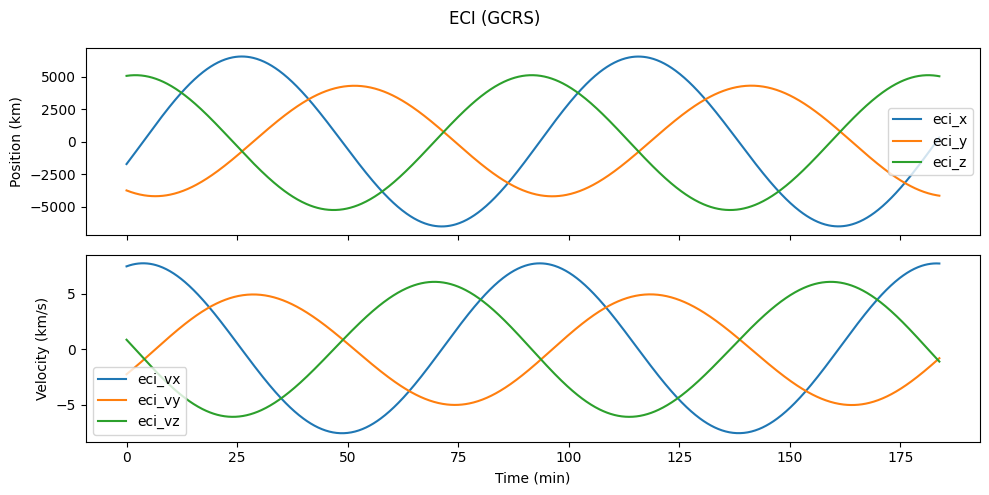

In [2]:
eci = generate_eci(times, sat)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
for k in ("eci_x", "eci_y", "eci_z"):
    ax1.plot(minutes, eci[k] / 1e3, label=k)
ax1.set_ylabel("Position (km)")
ax1.legend()

for k in ("eci_vx", "eci_vy", "eci_vz"):
    ax2.plot(minutes, eci[k] / 1e3, label=k)
ax2.set_ylabel("Velocity (km/s)")
ax2.set_xlabel("Time (min)")
ax2.legend()

fig.suptitle("ECI (GCRS)")
plt.tight_layout()
plt.show()

## ECEF Position & Velocity

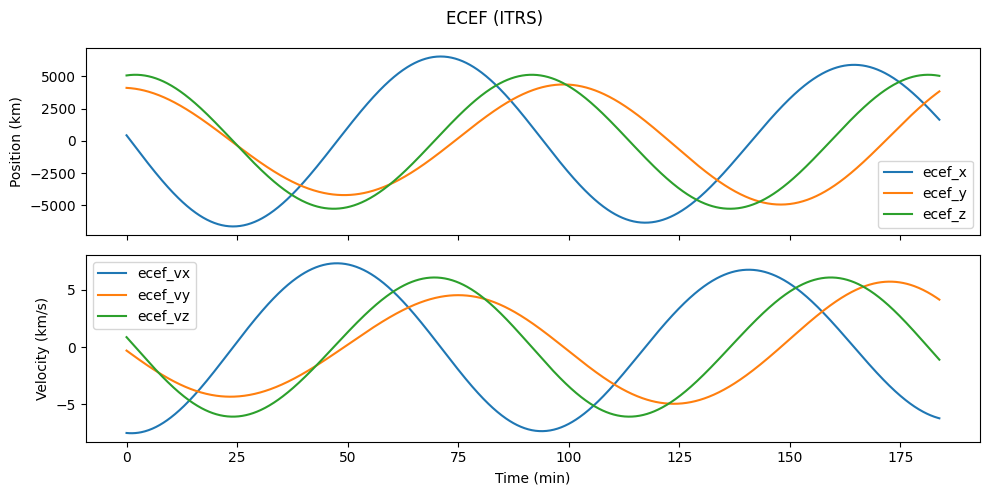

In [3]:
ecef = generate_ecef(times, sat)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
for k in ("ecef_x", "ecef_y", "ecef_z"):
    ax1.plot(minutes, ecef[k] / 1e3, label=k)
ax1.set_ylabel("Position (km)")
ax1.legend()

for k in ("ecef_vx", "ecef_vy", "ecef_vz"):
    ax2.plot(minutes, ecef[k] / 1e3, label=k)
ax2.set_ylabel("Velocity (km/s)")
ax2.set_xlabel("Time (min)")
ax2.legend()

fig.suptitle("ECEF (ITRS)")
plt.tight_layout()
plt.show()

## Latitude, Longitude, Altitude

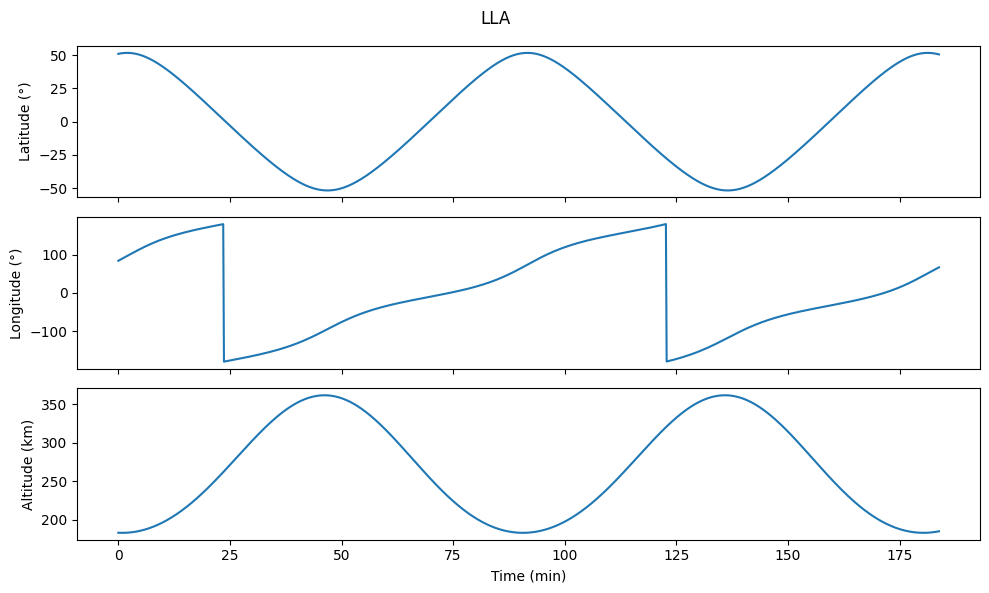

In [4]:
lla = generate_lla(times, sat)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(10, 6))

ax1.plot(minutes, lla["lat"])
ax1.set_ylabel("Latitude (\u00b0)")

ax2.plot(minutes, lla["lon"])
ax2.set_ylabel("Longitude (\u00b0)")

ax3.plot(minutes, lla["alt"] / 1e3)
ax3.set_ylabel("Altitude (km)")
ax3.set_xlabel("Time (min)")

fig.suptitle("LLA")
plt.tight_layout()
plt.show()

## Keplerian Elements

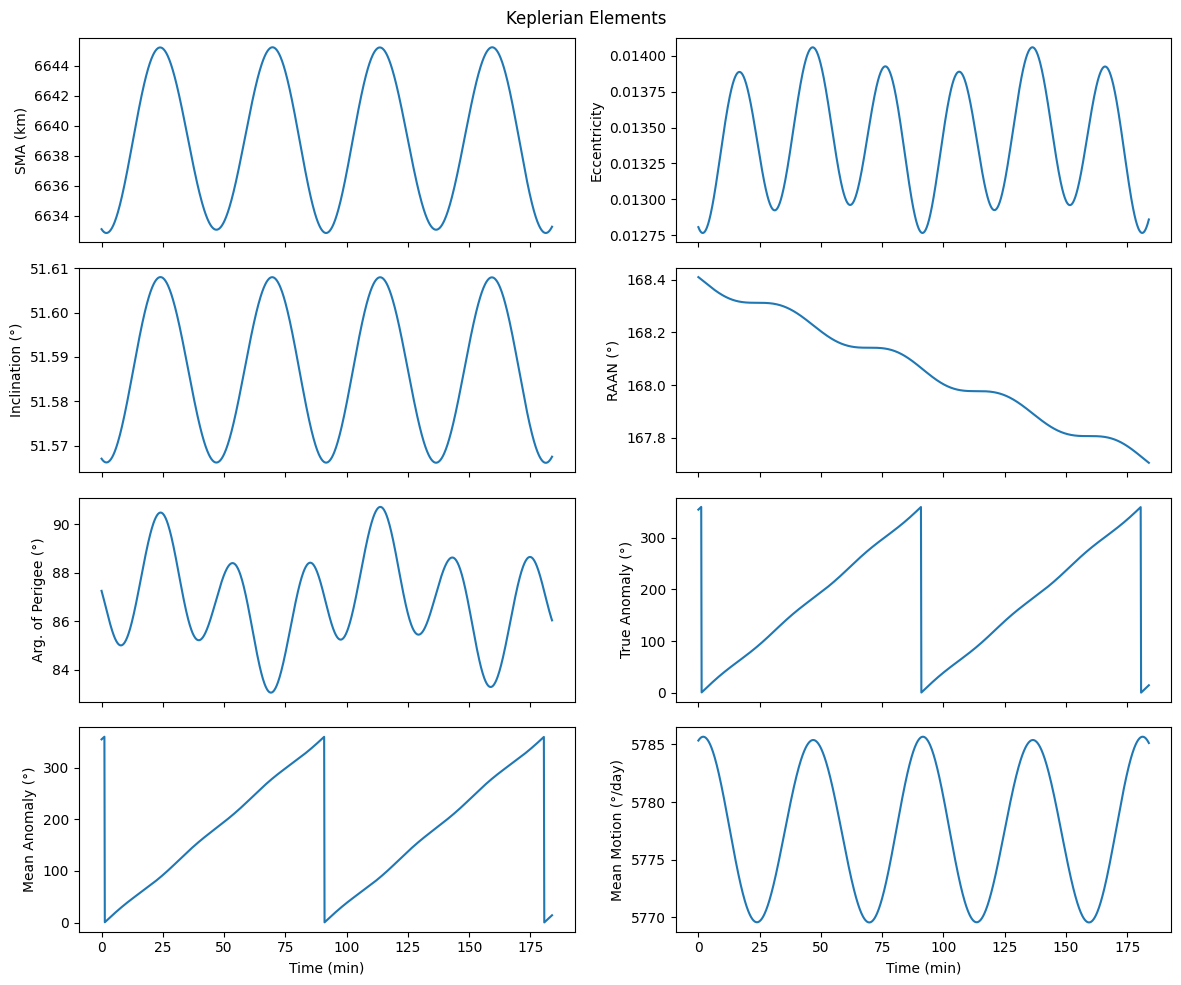

In [5]:
kep = generate_keplerian(times, sat)

fig, axes = plt.subplots(4, 2, sharex=True, figsize=(12, 10))

plots = [
    ("sma", "SMA (km)", 1e3),
    ("ecc", "Eccentricity", 1),
    ("inc", "Inclination (\u00b0)", 1),
    ("raan", "RAAN (\u00b0)", 1),
    ("aop", "Arg. of Perigee (\u00b0)", 1),
    ("ta", "True Anomaly (\u00b0)", 1),
    ("ma", "Mean Anomaly (\u00b0)", 1),
    ("mm", "Mean Motion (\u00b0/day)", 1),
]

for ax, (key, label, divisor) in zip(axes.ravel(), plots):
    ax.plot(minutes, kep[key] / divisor)
    ax.set_ylabel(label)

for ax in axes[-1]:
    ax.set_xlabel("Time (min)")

fig.suptitle("Keplerian Elements")
plt.tight_layout()
plt.show()

## Equinoctial Elements

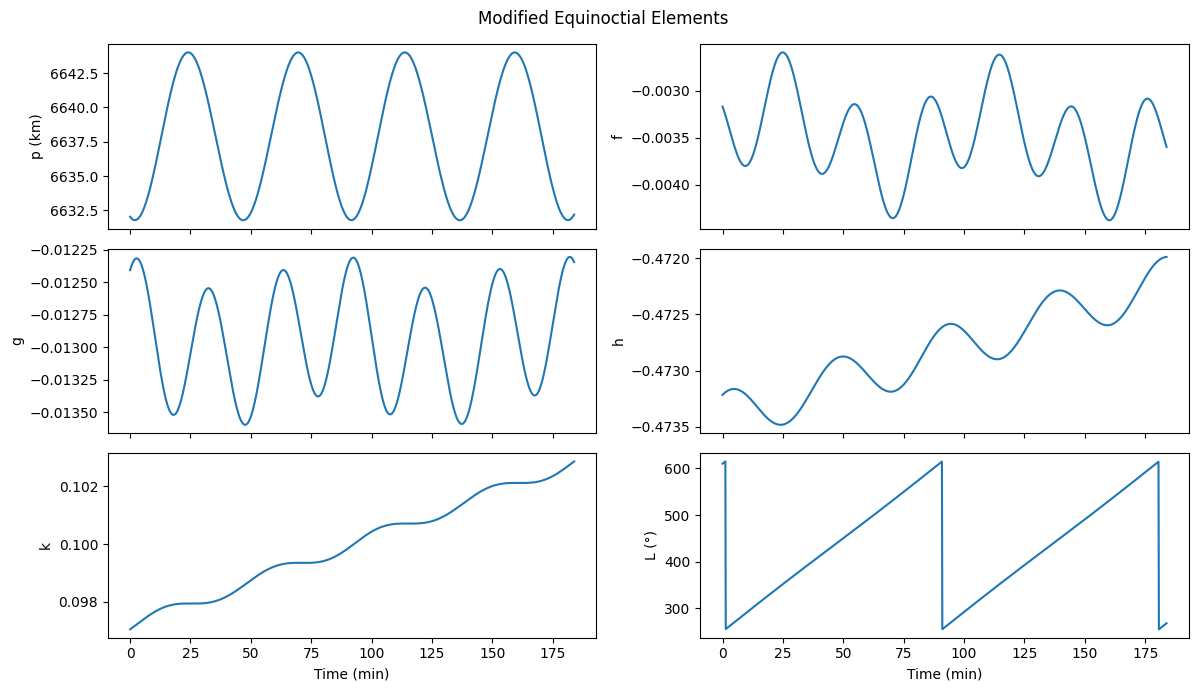

In [6]:
equi = generate_equinoctial(times, sat)

fig, axes = plt.subplots(3, 2, sharex=True, figsize=(12, 7))

plots = [
    ("p", "p (km)", 1e3),
    ("f", "f", 1),
    ("g", "g", 1),
    ("h", "h", 1),
    ("k", "k", 1),
    ("L", "L (\u00b0)", 1),
]

for ax, (key, label, divisor) in zip(axes.ravel(), plots):
    ax.plot(minutes, equi[key] / divisor)
    ax.set_ylabel(label)

for ax in axes[-1]:
    ax.set_xlabel("Time (min)")

fig.suptitle("Modified Equinoctial Elements")
plt.tight_layout()
plt.show()

## Sunlight Condition

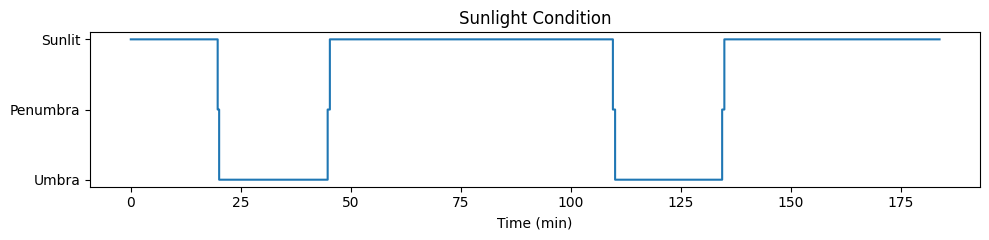

In [7]:
sun = generate_sunlight(times, sat)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.step(minutes, sun["sun"], where="mid")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Umbra", "Penumbra", "Sunlit"])
ax.set_xlabel("Time (min)")
ax.set_title("Sunlight Condition")
plt.tight_layout()
plt.show()

## Beta Angle

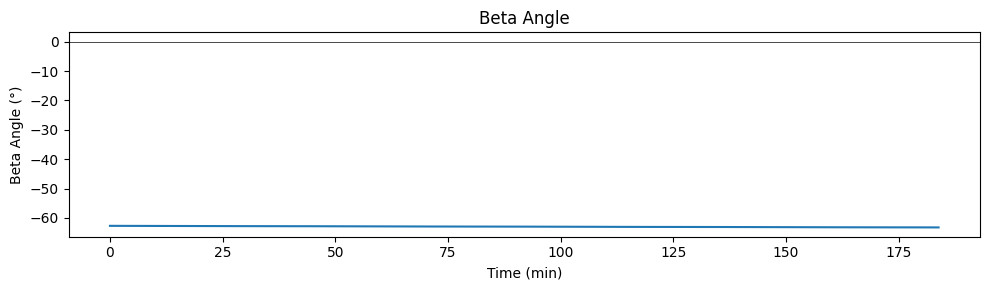

In [8]:
beta = generate_beta_angle(times, sat)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(minutes, beta["beta"])
ax.axhline(0, color="k", linewidth=0.5)
ax.set_ylabel("Beta Angle (\u00b0)")
ax.set_xlabel("Time (min)")
ax.set_title("Beta Angle")
plt.tight_layout()
plt.show()

## Local Solar Time

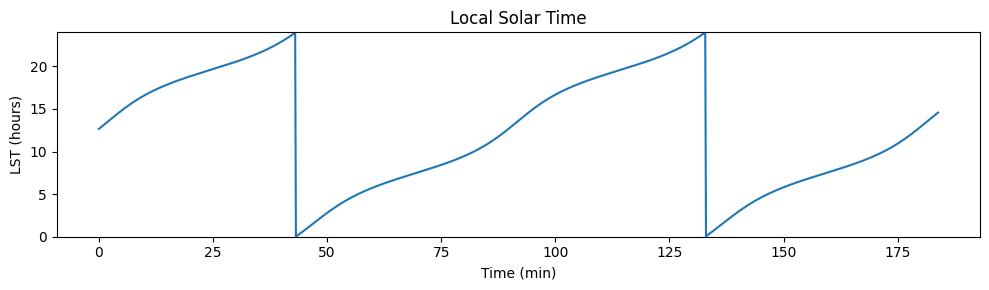

In [9]:
lst = generate_local_solar_time(times, sat)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(minutes, lst["lst"])
ax.set_ylabel("LST (hours)")
ax.set_xlabel("Time (min)")
ax.set_ylim(0, 24)
ax.set_title("Local Solar Time")
plt.tight_layout()
plt.show()

## Magnetic Field (ENU)

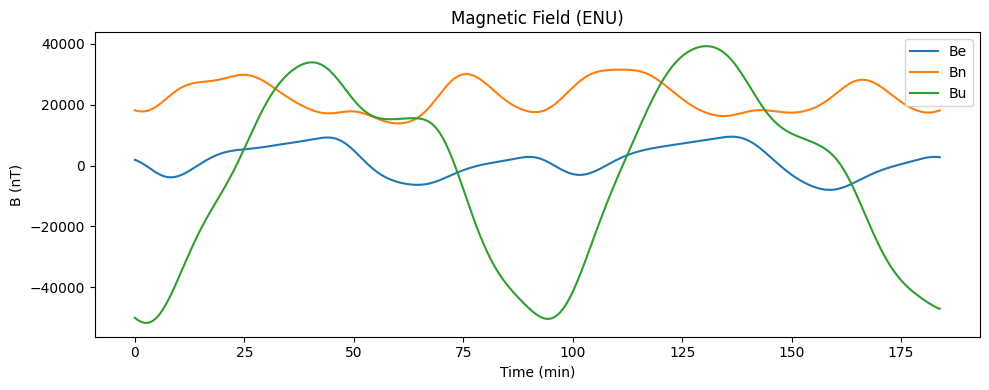

In [10]:
mag_enu = generate_magnetic_field_enu(times, sat)

fig, ax = plt.subplots(figsize=(10, 4))
for k in ("Be", "Bn", "Bu"):
    ax.plot(minutes, mag_enu[k], label=k)
ax.set_ylabel("B (nT)")
ax.set_xlabel("Time (min)")
ax.legend()
ax.set_title("Magnetic Field (ENU)")
plt.tight_layout()
plt.show()

## Magnetic Field (Total)

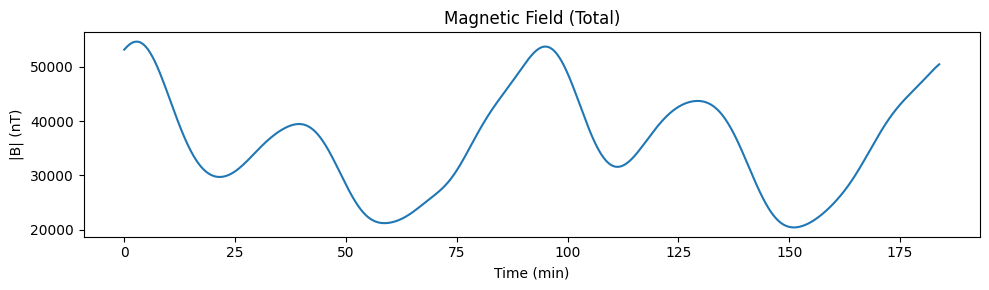

In [11]:
mag_total = generate_magnetic_field_total(times, sat)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(minutes, mag_total["Bt"])
ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (min)")
ax.set_title("Magnetic Field (Total)")
plt.tight_layout()
plt.show()

## Magnetic Field (ECEF)

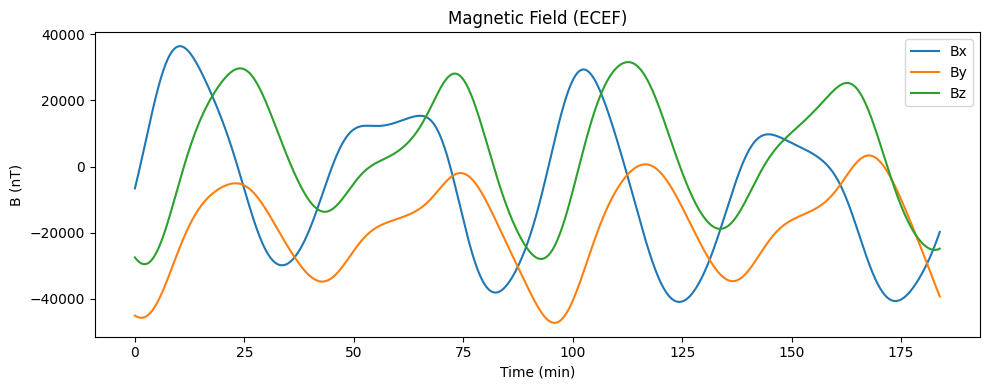

In [12]:
mag_ecef = generate_magnetic_field_ecef(times, sat)

fig, ax = plt.subplots(figsize=(10, 4))
for k in ("Bx", "By", "Bz"):
    ax.plot(minutes, mag_ecef[k], label=k)
ax.set_ylabel("B (nT)")
ax.set_xlabel("Time (min)")
ax.legend()
ax.set_title("Magnetic Field (ECEF)")
plt.tight_layout()
plt.show()